In [1]:
import os
import sys

import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.insert(0, os.path.abspath("/home1/smaruj/ledidi_akita/"))

from utils.df_utils import load_optimization_results, summarize_by_target, parse_dot_distance_from_dirname

In [2]:
BASE_DIR  = Path("/project2/fudenber_735/smaruj/sequence_design/ledidi_semifreddo_akita/optimizations/dots/results/")
PLOTS_DIR = Path("./../plots/")
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

NATURAL_DOTS_PATH = Path("/project2/fudenber_735/smaruj/sequence_design/ledidi_semifreddo_akita/analysis/natural_features/dots/mouse_convergent_dots_strength.tsv")

RESULT_DIRS = ["dot_d30", "dot_d50", "dot_d70"]
TARGETS     = [30, 50, 70]
FOLDS       = range(8)

In [3]:
df = load_optimization_results(RESULT_DIRS, BASE_DIR, FOLDS, parse_dot_distance_from_dirname)

In [4]:
df["dot_diff"]     = df["dot15_edited"] - df["dot15_orig"]
df["init_CTCFs_num"] = df["init_CTCFs_num_lo"] + df["init_CTCFs_num_hi"]
df["CTCFs_num"] = df["CTCFs_num_lo"] + df["CTCFs_num_hi"]

df["optimization_success"] = df["dot_diff"] > 0

print(f"Loaded {len(df)} windows across {df['fold'].nunique()} folds and {df['target'].nunique()} targets")
print(f"Successful optimizations: {df['optimization_success'].sum()} / {len(df)} ({100 * df['optimization_success'].mean():.1f}%)")

Loaded 1065 windows across 8 folds and 3 targets
Successful optimizations: 889 / 1065 (83.5%)


In [5]:
summary = summarize_by_target(df)
summary

,target,n_total,n_no_edits,n_no_depletion,success_rate_pct,mean_n_edits,mean_last_step
0,30.0,355,115,0,67.6,222.5,1984.5
1,50.0,355,48,0,86.5,127.3,1983.1
2,70.0,355,13,0,96.3,111.0,1988.4


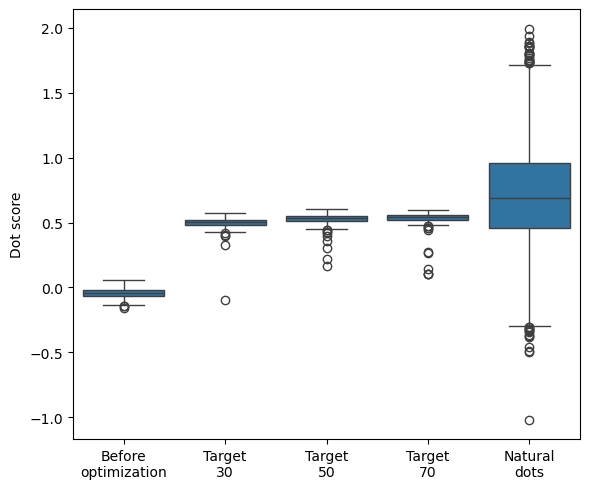

In [6]:
nat_df = pd.read_csv(NATURAL_DOTS_PATH, sep="\t")

successful = df[df["optimization_success"]]

parts = []

# (1) Original dot scores — one target only to avoid duplicate windows
orig_scores = successful[successful["target"] == TARGETS[0]][["dot15_orig"]].copy()
orig_scores["group"] = "Before\noptimization"
orig_scores = orig_scores.rename(columns={"dot15_orig": "dot_score"})
parts.append(orig_scores)

# (2) Edited dot scores per target
for target in TARGETS:
    edited = successful[successful["target"] == target][["dot15_edited"]].copy()
    edited["group"] = f"Target\n{target}"
    edited = edited.rename(columns={"dot15_edited": "dot_score"})
    parts.append(edited)

# (3) Natural dot scores
nat_scores = nat_df[["dot_strength"]].copy()
nat_scores["group"] = "Natural\ndots"
nat_scores = nat_scores.rename(columns={"dot_strength": "dot_score"})
parts.append(nat_scores)

plot_df = pd.concat(parts, ignore_index=True)
group_order = ["Before\noptimization"] + [f"Target\n{t}" for t in TARGETS] + ["Natural\ndots"]

fig, ax = plt.subplots(figsize=(6, 5))
sns.boxplot(data=plot_df, x="group", y="dot_score", order=group_order, ax=ax)
ax.set_xlabel("")
ax.set_ylabel("Dot score")

plt.tight_layout()
# plt.savefig(PLOTS_DIR / "dot_scores_boxplot.svg", format="svg")
plt.show()

In [ ]:
df["init_CTCFs_num"] = df["init_CTCFs_num_lo"] + df["init_CTCFs_num_hi"]
df["CTCFs_num"] = df["CTCFs_num_lo"] + df["CTCFs_num_hi"]

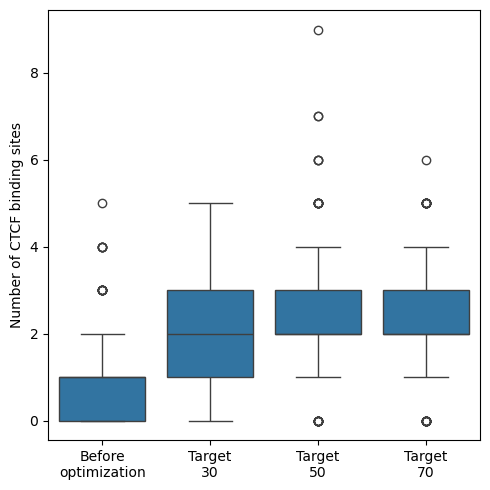

In [8]:
parts = []

# (1) Initial CTCF counts — one target only to avoid duplicate windows
orig_ctcf = successful[successful["target"] == TARGETS[0]][["init_CTCFs_num"]].copy()
orig_ctcf["group"] = "Before\noptimization"
orig_ctcf = orig_ctcf.rename(columns={"init_CTCFs_num": "n_CTCFs"})
parts.append(orig_ctcf)

# (2) Edited CTCF counts per target
for target in TARGETS:
    edited = successful[successful["target"] == target][["CTCFs_num"]].copy()
    edited["group"] = f"Target\n{target}"
    edited = edited.rename(columns={"CTCFs_num": "n_CTCFs"})
    parts.append(edited)

plot_df = pd.concat(parts, ignore_index=True)
group_order = ["Before\noptimization"] + [f"Target\n{t}" for t in TARGETS]

fig, ax = plt.subplots(figsize=(5, 5))
sns.boxplot(data=plot_df, x="group", y="n_CTCFs", order=group_order, ax=ax)
ax.set_xlabel("")
ax.set_ylabel("Number of CTCF binding sites")

plt.tight_layout()
plt.savefig(PLOTS_DIR / "ctcf_counts_boxplot.svg", format="svg")
plt.show()

In [11]:
def categorize_orientation_string(s):
    """
    Categorizes the CTCF orientation string.
    Note: Returns '>1 CTCF' if the motif is present, 
    even if only one '+' or '-' is found.
    """
    s = str(s)
    if s == "no" or s == "nan" or not s:
        return "no CTCF"
    elif "+" in s:
        return ">1 CTCF with +"
    elif "-" in s:
        return ">1 CTCF with -"
    else:
        return "no CTCF"

In [13]:
successful["cat_lo"] = successful["orientation_lo"].apply(categorize_orientation_string)
successful["cat_hi"] = successful["orientation_hi"].apply(categorize_orientation_string)

/tmp/SLURM_2918427/ipykernel_1783513/1543615234.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  successful["cat_lo"] = successful["orientation_lo"].apply(categorize_orientation_string)
/tmp/SLURM_2918427/ipykernel_1783513/1543615234.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  successful["cat_hi"] = successful["orientation_hi"].apply(categorize_orientation_string)


In [14]:
categories = [">1 CTCF with +", ">1 CTCF with -", "no CTCF"]

In [15]:
contingency_table = pd.crosstab(
    successful["cat_hi"], 
    successful["cat_lo"]
).reindex(index=categories, columns=categories, fill_value=0)

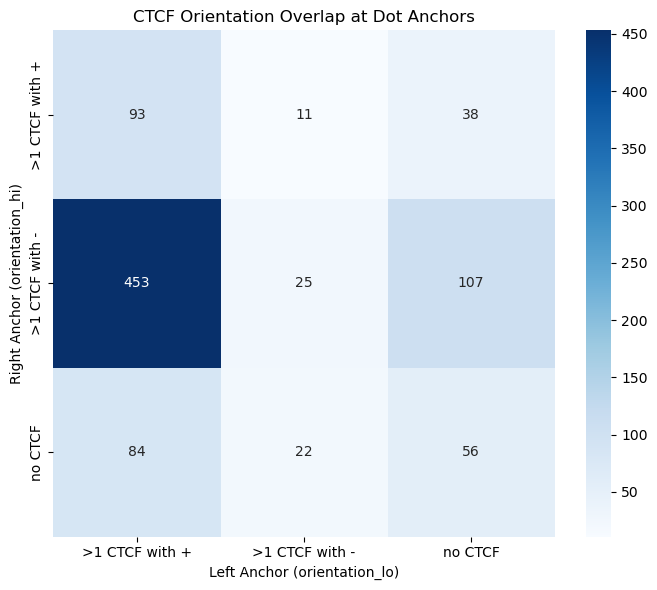

In [18]:
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    contingency_table, 
    annot=True, 
    fmt="d", 
    cmap="Blues", 
    ax=ax
)

ax.set_xlabel("Left Anchor (orientation_lo)")
ax.set_ylabel("Right Anchor (orientation_hi)")
ax.set_title("CTCF Orientation Overlap at Dot Anchors")

plt.tight_layout()
plt.savefig(PLOTS_DIR / "ctcf_orientation_heatmap.svg", format="svg")
plt.show() # Uncomment if running locally